# Score SDE Training on Kaggle

This notebook sets up and runs training for Score-based Generative Models using SDEs on Kaggle.

In [ ]:
import sys
import os

# Add the score_sde code directory to Python path
code_dir = '/kaggle/input/score-sde-code/score_final/score_sde_pytorch'
sys.path.insert(0, code_dir)

# Set working directory for outputs
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/samples', exist_ok=True)

print("Code directory:", code_dir)
print("Working directory:", os.getcwd())

## Import run_lib without TensorFlow dependencies

We'll manually load and modify run_lib to skip TensorFlow imports:

In [2]:
# Import PyTorch FIRST, before patching
import torch
import numpy as np

# Pre-import torch._dynamo to avoid circular import issues
try:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
except:
    pass

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


import torch
from torch.utils import tensorboard
import torchvision.datasets as torch_datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import sys
import os
import types
import itertools
import re

print(f"✓ PyTorch {torch.__version__} imported (before patching)")

# Create a comprehensive fake TensorFlow module
class FakeModule:
    def __init__(self, name='FakeModule'):
        self._name = name
        self.__version__ = '2.18.0'
        self.__file__ = '/fake/path/__init__.py'
        self.__spec__ = types.SimpleNamespace(origin='/fake/path/__init__.py')
    def __call__(self, *args, **kwargs):
        return self
    def __getattr__(self, name):
        return FakeModule(f'{self._name}.{name}')
    def __enter__(self):
        return self
    def __exit__(self, *args):
        pass
    def __getitem__(self, key):
        return self

class FakeTF(FakeModule):
    __version__ = '2.18.0'
    __file__ = '/fake/tensorflow/__init__.py'
    
    class io:
        class gfile:
            @staticmethod
            def makedirs(path):
                os.makedirs(path, exist_ok=True)
            
            @staticmethod
            def exists(path):
                return os.path.exists(path)
            
            @staticmethod
            def GFile(path, mode='r'):
                """Return a standard Python file object"""
                return open(path, mode)

# Patch TensorFlow modules
sys.modules['tensorflow'] = FakeTF('tensorflow')
sys.modules['tensorflow_gan'] = FakeModule('tensorflow_gan')
sys.modules['tensorflow_hub'] = FakeModule('tensorflow_hub')
sys.modules['tensorflow_probability'] = FakeModule('tensorflow_probability')
sys.modules['tensorflow_datasets'] = FakeModule('tensorflow_datasets')

print("✓ TensorFlow modules patched")

# --- PATCH START: Fix upfirdn2d_native bug BEFORE importing models ---
# Define the correct implementation
def upfirdn2d_native_fixed(
    input, kernel, up_x, up_y, down_x, down_y, pad_x0, pad_x1, pad_y0, pad_y1
):
    """Fixed upfirdn2d_native that properly handles tensor reshaping."""
    _, channel, in_h, in_w = input.shape
    input = input.reshape(-1, in_h, in_w, 1)

    _, in_h, in_w, minor = input.shape
    kernel_h, kernel_w = kernel.shape

    out = input.view(-1, in_h, 1, in_w, 1, minor)
    out = F.pad(out, [0, 0, 0, up_x - 1, 0, 0, 0, up_y - 1])
    out = out.view(-1, in_h * up_y, in_w * up_x, minor)

    out = F.pad(
        out, [0, 0, max(pad_x0, 0), max(pad_x1, 0), max(pad_y0, 0), max(pad_y1, 0)]
    )
    out = out[
        :,
        max(-pad_y0, 0) : out.shape[1] - max(-pad_y1, 0),
        max(-pad_x0, 0) : out.shape[2] - max(-pad_x1, 0),
        :,
    ]

    out = out.permute(0, 3, 1, 2)
    out = out.reshape(
        [-1, 1, in_h * up_y + pad_y0 + pad_y1, in_w * up_x + pad_x0 + pad_x1]
    )
    w = torch.flip(kernel, [0, 1]).view(1, 1, kernel_h, kernel_w)
    out = F.conv2d(out, w)
    out = out.reshape(
        -1,
        minor,
        in_h * up_y + pad_y0 + pad_y1 - kernel_h + 1,
        in_w * up_x + pad_x0 + pad_x1 - kernel_w + 1,
    )
    out = out.permute(0, 2, 3, 1)
    out = out[:, ::down_y, ::down_x, :]

    out_h = (in_h * up_y + pad_y0 + pad_y1 - kernel_h) // down_y + 1
    out_w = (in_w * up_x + pad_x0 + pad_x1 - kernel_w) // down_x + 1

    return out.view(-1, channel, out_h, out_w)

# Pre-import and patch the op.upfirdn2d module BEFORE any models are imported
try:
    # Force import of the module
    import importlib.util
    upfirdn2d_path = '/kaggle/input/score-sde-code/score_final/score_sde_pytorch/op/upfirdn2d.py'
    spec = importlib.util.spec_from_file_location("op.upfirdn2d", upfirdn2d_path)
    upfirdn2d_module = importlib.util.module_from_spec(spec)
    
    # Patch before loading
    sys.modules['op.upfirdn2d'] = upfirdn2d_module
    spec.loader.exec_module(upfirdn2d_module)
    
    # Now patch the function
    upfirdn2d_module.upfirdn2d_native = upfirdn2d_native_fixed
    print("✓ Pre-patched op.upfirdn2d.upfirdn2d_native")
except Exception as e:
    print(f"⚠ Error pre-patching upfirdn2d: {e}")
# --- PATCH END ---

# Wrapper class to make PyTorch DataLoader behave like TF dataset
class InfiniteDataLoader:
    """Infinite DataLoader that cycles through data forever"""
    def __init__(self, dataloader):
        self.dataloader = dataloader
    
    def __iter__(self):
        # Create an infinite cycle through the dataloader
        while True:
            for batch in self.dataloader:
                images, labels = batch
                # Keep NCHW format (PyTorch native) - DO NOT convert to NHWC
                # The model expects NCHW format
                
                class TensorWrapper:
                    """Wrapper that returns numpy array in NCHW format"""
                    def __init__(self, data):
                        self.data = data
                    def _numpy(self):
                        # Return as numpy array in NCHW format
                        # This is what run_lib expects
                        return self.data.cpu().numpy()
                
                yield {'image': TensorWrapper(images), 'label': labels}

# Create patched dataset functions
def get_data_scaler(config):
    """Data normalizer. Assume data are always in [0, 1]."""
    if config.data.centered:
        # Return scaler that works with NCHW format
        return lambda x: x * 2. - 1.
    else:
        return lambda x: x

def get_data_inverse_scaler(config):
    """Inverse data normalizer."""
    if config.data.centered:
        return lambda x: (x + 1.) / 2.
    else:
        return lambda x: x

def get_dataset(config, uniform_dequantization=False, evaluation=False):
    """Create PyTorch datasets wrapped to look like TF datasets."""
    
    if config.data.dataset == 'CIFAR10':
        # Use PyTorch's built-in CIFAR10 dataset
        transform = transforms.Compose([
            transforms.ToTensor(),
        ])
        
        # SINGLE CLASS TRAINING: Filter for only one class
        # CIFAR-10 classes: 0=airplane, 1=automobile, 2=bird, 3=cat, 4=deer,
        #                   5=dog, 6=frog, 7=horse, 8=ship, 9=truck
        TARGET_CLASS = 3 # automobile - change this to train on different class
        
        full_train_dataset = torch_datasets.CIFAR10(
            root='/kaggle/working/data',
            train=True,
            download=True,
            transform=transform
        )
        
        full_eval_dataset = torch_datasets.CIFAR10(
            root='/kaggle/working/data',
            train=False,
            download=True,
            transform=transform
        )
        
        # Filter for single class
        train_indices = [i for i, (_, label) in enumerate(full_train_dataset) if label == TARGET_CLASS]
        eval_indices = [i for i, (_, label) in enumerate(full_eval_dataset) if label == TARGET_CLASS]
        
        from torch.utils.data import Subset
        train_dataset = Subset(full_train_dataset, train_indices)
        eval_dataset = Subset(full_eval_dataset, eval_indices)
        
        class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                       'dog', 'frog', 'horse', 'ship', 'truck']
        print(f"✓ Single-class training: {class_names[TARGET_CLASS]} (class {TARGET_CLASS})")
        print(f"  Train samples: {len(train_dataset)}, Eval samples: {len(eval_dataset)}")
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.training.batch_size,
            shuffle=True,
            num_workers=0,  # Set to 0 to avoid multiprocessing issues
            drop_last=True,
            pin_memory=True
        )
        
        eval_loader = DataLoader(
            eval_dataset,
            batch_size=config.eval.batch_size,
            shuffle=False,
            num_workers=0,
            drop_last=True,
            pin_memory=True
        )
        
        # Wrap in infinite iterators
        train_ds = InfiniteDataLoader(train_loader)
        eval_ds = InfiniteDataLoader(eval_loader)
        
        # Return in expected format
        return train_ds, eval_ds, {'channels': 3, 'image_size': 32}
    else:
        raise NotImplementedError(f'Dataset {config.data.dataset} not implemented!')

# Create custom datasets module and inject it
datasets = types.ModuleType('datasets')
datasets.get_dataset = get_dataset
datasets.get_data_scaler = get_data_scaler
datasets.get_data_inverse_scaler = get_data_inverse_scaler
sys.modules['datasets'] = datasets

print("✓ Custom datasets module created and injected")

# Import other score_sde modules
import losses
import sampling
from models import utils as mutils
from models.ema import ExponentialMovingAverage
import sde_lib

print("✓ Score SDE modules imported")

# --- PATCH START: Fix sde_lib VESDE discretize device mismatch ---
try:
    # Patch VESDE.discretize to handle device mismatch
    original_vesde_discretize = sde_lib.VESDE.discretize
    
    def vesde_discretize_fixed(self, x, t):
        """SMLD(NCSN) discretization with device-aware indexing."""
        timestep = (t * (self.N - 1) / self.T).long()
        # Move timestep to CPU for indexing, then move result back to t.device
        timestep_cpu = timestep.cpu()
        sigma = self.discrete_sigmas[timestep_cpu].to(t.device)
        adjacent_sigma = torch.where(
            timestep == 0, 
            torch.zeros_like(t),
            self.discrete_sigmas[torch.clamp(timestep_cpu - 1, min=0)].to(t.device)
        )
        f = torch.zeros_like(x)
        G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)
        return f, G
    
    sde_lib.VESDE.discretize = vesde_discretize_fixed
    print("✓ Patched sde_lib.VESDE.discretize for device compatibility")
except Exception as e:
    print(f"⚠ Error patching VESDE.discretize: {e}")
# --- PATCH END ---

# --- PATCH START: Fix upfirdn2d after imports ---
try:
    # Patch via multiple paths to ensure it's fixed everywhere
    from op import upfirdn2d as upfirdn2d_mod
    upfirdn2d_mod.upfirdn2d_native = upfirdn2d_native_fixed
    print("✓ Post-patched op.upfirdn2d.upfirdn2d_native")
    
    # Also patch in models.up_or_down_sampling if it imported it
    from models import up_or_down_sampling
    if hasattr(up_or_down_sampling, 'upfirdn2d'):
        # The upfirdn2d function in up_or_down_sampling calls upfirdn2d_native
        # We need to patch the module it imports from
        import op.upfirdn2d
        op.upfirdn2d.upfirdn2d_native = upfirdn2d_native_fixed
        print("✓ Patched op.upfirdn2d via models.up_or_down_sampling")
except Exception as e:
    print(f"⚠ Error post-patching: {e}")
# --- PATCH END ---

# Load run_lib and patch it to handle PyTorch format correctly
run_lib_path = '/kaggle/input/score-sde-code/score_final/score_sde_pytorch/run_lib.py'

with open(run_lib_path, 'r') as f:
    run_lib_code = f.read()

# Strategy: Replace the data loading section entirely to ensure NCHW format
# Find all places where batches are loaded and replace the two-line pattern
replacements_made = 0

# Pattern 1: Main training batch loading
old_pattern1 = """batch = torch.from_numpy(next(train_iter)['image']._numpy()).to(config.device).float()
    batch = batch.permute(0, 3, 1, 2)"""
new_pattern1 = """batch = torch.from_numpy(next(train_iter)['image']._numpy()).to(config.device).float()
    # batch already in NCHW format, no permute needed"""

if old_pattern1 in run_lib_code:
    run_lib_code = run_lib_code.replace(old_pattern1, new_pattern1)
    replacements_made += 1
    print("✓ Replaced main training batch loading")

# Pattern 2: Eval batch loading (inside training loop)
old_pattern2 = """eval_batch = torch.from_numpy(next(eval_iter)['image']._numpy()).to(config.device).float()
      eval_batch = eval_batch.permute(0, 3, 1, 2)"""
new_pattern2 = """eval_batch = torch.from_numpy(next(eval_iter)['image']._numpy()).to(config.device).float()
      # eval_batch already in NCHW format, no permute needed"""

if old_pattern2 in run_lib_code:
    run_lib_code = run_lib_code.replace(old_pattern2, new_pattern2)
    replacements_made += 1
    print("✓ Replaced eval batch loading (training loop)")

# Pattern 3: Eval function batch loading (from iterator)
old_pattern3 = """eval_batch = torch.from_numpy(batch['image']._numpy()).to(config.device).float()
        eval_batch = eval_batch.permute(0, 3, 1, 2)"""
new_pattern3 = """eval_batch = torch.from_numpy(batch['image']._numpy()).to(config.device).float()
        # eval_batch already in NCHW format, no permute needed"""

run_lib_code = run_lib_code.replace(old_pattern3, new_pattern3)
replacements_made += len([m for m in re.finditer(re.escape(old_pattern3), run_lib_code)])

# Pattern 4: Another eval batch variation
old_pattern4 = """eval_batch = torch.from_numpy(batch['image']._numpy()).to(config.device).float()
          eval_batch = eval_batch.permute(0, 3, 1, 2)"""
new_pattern4 = """eval_batch = torch.from_numpy(batch['image']._numpy()).to(config.device).float()
          # eval_batch already in NCHW format, no permute needed"""

run_lib_code = run_lib_code.replace(old_pattern4, new_pattern4)

print(f"✓ run_lib code patched - Made {replacements_made}+ replacements")
print("✓ All NHWC->NCHW permutations removed")

# Create module namespace
namespace = {
    'torch': torch,
    'np': np,
    'tensorboard': tensorboard,
    'losses': losses,
    'sampling': sampling,
    'mutils': mutils,
    'ExponentialMovingAverage': ExponentialMovingAverage,
    'datasets': datasets,
    'sde_lib': sde_lib,
    'tf': sys.modules['tensorflow'],
    'tfgan': sys.modules['tensorflow_gan'],
    'os': os,
    'time': __import__('time'),
    'gc': __import__('gc'),
    'io': __import__('io'),
    'logging': __import__('logging'),
}

# Execute run_lib
exec(run_lib_code, namespace)

# Extract train function
train = namespace['train']

# Create run_lib module
run_lib = types.ModuleType('run_lib')
run_lib.train = train

print("✓ run_lib.train function loaded successfully")
print("✓ Ready for training (Pure PyTorch mode)")
print("\nNote: Using PyTorch's native CIFAR10 dataset (infinite iterator)")
print("Note: Data format: NCHW (PyTorch) -> numpy NCHW -> torch NCHW (no permute!)")
print("Note: FID/IS evaluation will be skipped")

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: Tesla P100-PCIE-16GB
✓ PyTorch 2.6.0+cu124 imported (before patching)
✓ TensorFlow modules patched
✓ Pre-patched op.upfirdn2d.upfirdn2d_native
✓ Custom datasets module created and injected
✓ Score SDE modules imported
✓ Patched sde_lib.VESDE.discretize for device compatibility
✓ Post-patched op.upfirdn2d.upfirdn2d_native
✓ Patched op.upfirdn2d via models.up_or_down_sampling
✓ Replaced main training batch loading
✓ Replaced eval batch loading (training loop)
✓ run_lib code patched - Made 2+ replacements
✓ All NHWC->NCHW permutations removed
✓ run_lib.train function loaded successfully
✓ Ready for training (Pure PyTorch mode)

Note: Using PyTorch's native CIFAR10 dataset (infinite iterator)
Note: Data format: NCHW (PyTorch) -> numpy NCHW -> torch NCHW (no permute!)
Note: FID/IS evaluation will be skipped


In [3]:
# Clear any existing models from GPU memory first
import torch
import gc

# Force garbage collection and clear CUDA cache
gc.collect()
torch.cuda.empty_cache()

# Delete any existing model variables if they exist
for var_name in ['score_model', 'model', 'ema', 'optimizer', 'state']:
    if var_name in dir():
        try:
            exec(f'del {var_name}')
        except:
            pass

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory before loading config:")
print(f"  Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"  Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# ============================================================================
# MODEL CONFIGURATION SELECTOR
# ============================================================================
# Choose one of the following configurations by uncommenting the desired line:
# 
# Option 1: VE-SDE with NCSN++ (discrete)
# from configs.ve import cifar10_ncsnpp
# config = cifar10_ncsnpp.get_config()
#
# Option 2: VP-SDE with DDPM++ 
from configs.vp import cifar10_ddpmpp
config = cifar10_ddpmpp.get_config()
#
# Option 3: VE-SDE with DDPM
# from configs.ve import cifar10_ddpm
# config = cifar10_ddpm.get_config()
#
# Option 4: VE-SDE with NCSN++ (continuous)
# from configs.ve import cifar10_ncsnpp_continuous
# config = cifar10_ncsnpp_continuous.get_config()
# ============================================================================

print(f"\n✓ Configuration loaded: {config.model.name} with {config.training.sde} SDE")

# Ensure device is set correctly
if not hasattr(config, 'device'):
    config.device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Override some settings for Kaggle environment
# Use batch size that divides evenly into 5000 (single class dataset size)
# model - REDUCED SIZE to fit in GPU memory
model = config.model

model.nf = 128  # REDUCED from 128 to 64 to save memory
model.ch_mult = (1, 2, 2, 2)
model.num_res_blocks = 1  # REDUCED from 8 to 4 to save memory

config.training.batch_size = 64  # REDUCED from 100 to 64 to save memory
config.training.n_iters = 100000
config.training.snapshot_freq = 10000
config.training.log_freq = 50
config.eval.batch_size = 64  # REDUCED from 100 to 64 to save memory
config.data.dataset = 'CIFAR10'
config.training.workdir = '/kaggle/working/checkpoints4'

print("\nConfiguration applied successfully!")
print(f"  - Model: {config.model.name}")
print(f"  - SDE Type: {config.training.sde}")
print(f"  - Dataset: {config.data.dataset}")
print(f"  - Batch size: {config.training.batch_size}")
print(f"  - Training iterations: {config.training.n_iters:,}")
print(f"\n⚠️ Model size REDUCED to fit GPU memory:")
print(f"  - nf: {model.nf}")
print(f"  - num_res_blocks: {model.num_res_blocks}")
print(f"  - batch_size: {config.training.batch_size}")

GPU memory before loading config:
  Allocated: 0.00 GB
  Reserved: 0.00 GB

✓ Configuration loaded: ncsnpp with vpsde SDE

Configuration applied successfully!
  - Model: ncsnpp
  - SDE Type: vpsde
  - Dataset: CIFAR10
  - Batch size: 64
  - Training iterations: 100,000

⚠️ Model size REDUCED to fit GPU memory:
  - nf: 128
  - num_res_blocks: 1
  - batch_size: 64


✓ Starting training...

⚠ Checkpoint not found: gfdlkj.pth
  Starting training from scratch

Training Configuration:
  - Model: ncsnpp
  - Dataset: CIFAR-10 Automobile class (5000 samples)
  - Batch size: 64
  - Total iterations: 100,000
  - Starting from step: 0
  - Remaining iterations: 100,000
  - Log frequency: Every 50 steps
  - Checkpoint frequency: Every 10,000 steps
  - Working directory: /kaggle/working/checkpoints4

Note: FID evaluation is disabled (no TensorFlow GAN)
Training will display loss and step information below.



100%|██████████| 170M/170M [00:07<00:00, 22.0MB/s] 


✓ Single-class training: cat (class 3)
  Train samples: 5000, Eval samples: 1000

[Step     50/100000] Speed: 5.23 steps/sec (current) | 1.69 steps/sec (overall) | ETA: 5h 18m

[Step    100/100000] Speed: 5.23 steps/sec (current) | 2.56 steps/sec (overall) | ETA: 5h 18m

[Step    150/100000] Speed: 5.23 steps/sec (current) | 3.08 steps/sec (overall) | ETA: 5h 18m

[Step    200/100000] Speed: 5.23 steps/sec (current) | 3.43 steps/sec (overall) | ETA: 5h 18m

[Step    250/100000] Speed: 5.23 steps/sec (current) | 3.68 steps/sec (overall) | ETA: 5h 18m

[Step    300/100000] Speed: 5.22 steps/sec (current) | 3.87 steps/sec (overall) | ETA: 5h 18m

[Step    350/100000] Speed: 5.22 steps/sec (current) | 4.01 steps/sec (overall) | ETA: 5h 17m

[Step    400/100000] Speed: 5.22 steps/sec (current) | 4.13 steps/sec (overall) | ETA: 5h 17m

[Step    450/100000] Speed: 5.22 steps/sec (current) | 4.23 steps/sec (overall) | ETA: 5h 17m

[Step    500/100000] Speed: 5.22 steps/sec (current) | 4.31 ste

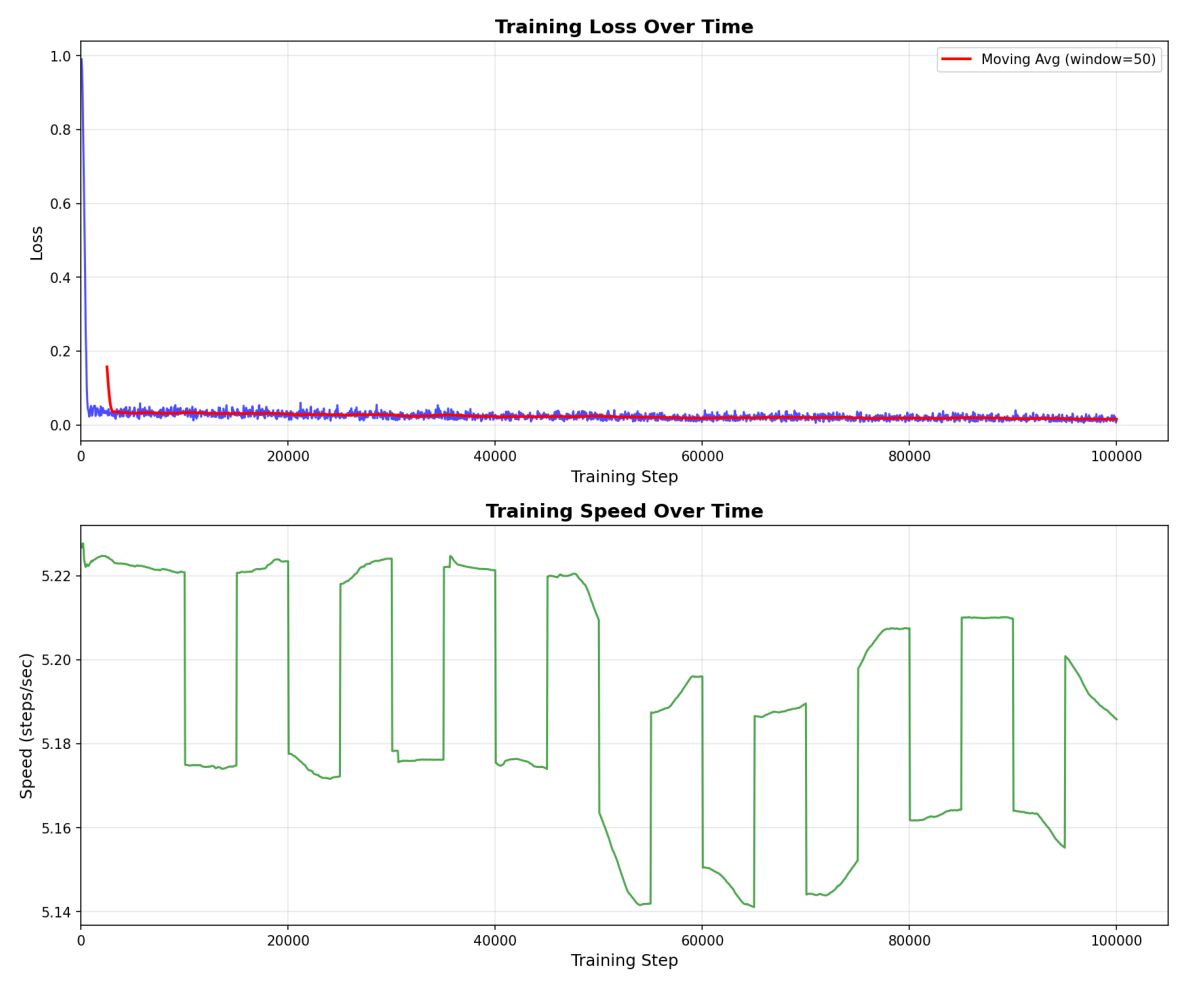


✓ Training completed!


In [5]:
import time
from collections import deque
import matplotlib.pyplot as plt

print("✓ Starting training...")
print("=" * 50)

# Resume from checkpoint if it exists
resume_checkpoint = 'gfdlkj.pth'
initial_step = 0

if os.path.exists(resume_checkpoint):
    print(f"\n🔄 Resuming from checkpoint: {resume_checkpoint}")
    print("Loading checkpoint state...")
    
    try:
        checkpoint = torch.load(resume_checkpoint, map_location=config.device, weights_only=False)
        initial_step = checkpoint.get('step', 0)
        print(f"✓ Checkpoint loaded from step {initial_step}")
        print(f"  Will resume training from step {initial_step + 1}")
    except Exception as e:
        print(f"⚠ Error loading checkpoint: {e}")
        print("  Starting training from scratch instead")
        resume_checkpoint = None
        initial_step = 0
else:
    print(f"\n⚠ Checkpoint not found: {resume_checkpoint}")
    print("  Starting training from scratch")
    resume_checkpoint = None

print(f"\nTraining Configuration:")
print(f"  - Model: {config.model.name}")
print(f"  - Dataset: CIFAR-10 Automobile class (5000 samples)")
print(f"  - Batch size: {config.training.batch_size}")
print(f"  - Total iterations: {config.training.n_iters:,}")
print(f"  - Starting from step: {initial_step}")
print(f"  - Remaining iterations: {config.training.n_iters - initial_step:,}")
print(f"  - Log frequency: Every {config.training.log_freq} steps")
print(f"  - Checkpoint frequency: Every {config.training.snapshot_freq:,} steps")
print(f"  - Working directory: {config.training.workdir}")
print("\nNote: FID evaluation is disabled (no TensorFlow GAN)")
print("Training will display loss and step information below.\n")
print("=" * 50)

# Create directory for training plots
os.makedirs('/kaggle/working/training_plots', exist_ok=True)

# Training metrics tracking
class TrainingMetrics:
    def __init__(self):
        self.steps = []
        self.losses = []
        self.speeds = []
        self.timestamps = []
        
    def add(self, step, loss, speed):
        self.steps.append(step)
        self.losses.append(loss)
        self.speeds.append(speed)
        self.timestamps.append(time.time())
    
    def plot_and_save(self):
        if len(self.steps) < 2:
            return
        
        # Create figure with subplots
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot 1: Training Loss
        axes[0].plot(self.steps, self.losses, 'b-', linewidth=1.5, alpha=0.7)
        axes[0].set_xlabel('Training Step', fontsize=12)
        axes[0].set_ylabel('Loss', fontsize=12)
        axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim(left=0)
        
        # Add moving average for loss
        if len(self.losses) >= 10:
            window = min(50, len(self.losses) // 10)
            moving_avg = np.convolve(self.losses, np.ones(window)/window, mode='valid')
            moving_avg_steps = self.steps[window-1:]
            axes[0].plot(moving_avg_steps, moving_avg, 'r-', linewidth=2, label=f'Moving Avg (window={window})')
            axes[0].legend()
        
        # Plot 2: Training Speed
        axes[1].plot(self.steps, self.speeds, 'g-', linewidth=1.5, alpha=0.7)
        axes[1].set_xlabel('Training Step', fontsize=12)
        axes[1].set_ylabel('Speed (steps/sec)', fontsize=12)
        axes[1].set_title('Training Speed Over Time', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlim(left=0)
        
        plt.tight_layout()
        
        # Save the plot
        plot_path = '/kaggle/working/training_plots/training_metrics.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        # Also create individual plots for better visibility
        # Loss plot only
        plt.figure(figsize=(12, 6))
        plt.plot(self.steps, self.losses, 'b-', linewidth=1.5, alpha=0.7, label='Loss')
        if len(self.losses) >= 10:
            window = min(50, len(self.losses) // 10)
            moving_avg = np.convolve(self.losses, np.ones(window)/window, mode='valid')
            moving_avg_steps = self.steps[window-1:]
            plt.plot(moving_avg_steps, moving_avg, 'r-', linewidth=2, label=f'Moving Avg (window={window})')
        plt.xlabel('Training Step', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.title('Training Loss Over Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xlim(left=0)
        plt.tight_layout()
        plt.savefig('/kaggle/working/training_plots/loss_curve.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        # Speed plot only
        plt.figure(figsize=(12, 6))
        plt.plot(self.steps, self.speeds, 'g-', linewidth=1.5, alpha=0.7)
        plt.xlabel('Training Step', fontsize=12)
        plt.ylabel('Speed (steps/sec)', fontsize=12)
        plt.title('Training Speed Over Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.xlim(left=0)
        plt.tight_layout()
        plt.savefig('/kaggle/working/training_plots/speed_curve.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"📊 Training plots saved to /kaggle/working/training_plots/")

# Initialize metrics tracker
metrics = TrainingMetrics()

# Create a wrapper to track steps per second
class StepTimer:
    def __init__(self, window_size=100, initial_step=0):
        self.start_time = time.time()
        self.last_step = initial_step
        self.last_time = self.start_time
        self.step_times = deque(maxlen=window_size)
        self.total_steps = initial_step
        
    def update(self, current_step, loss=None):
        current_time = time.time()
        steps_done = current_step - self.last_step
        time_elapsed = current_time - self.last_time
        
        if steps_done > 0 and time_elapsed > 0:
            steps_per_sec = steps_done / time_elapsed
            self.step_times.append(steps_per_sec)
            self.total_steps = current_step
            
            # Calculate statistics
            avg_steps_per_sec = sum(self.step_times) / len(self.step_times)
            total_elapsed = current_time - self.start_time
            overall_steps_per_sec = (current_step - initial_step) / total_elapsed if total_elapsed > 0 else 0
            
            # Estimate time remaining
            steps_remaining = config.training.n_iters - current_step
            eta_seconds = steps_remaining / avg_steps_per_sec if avg_steps_per_sec > 0 else 0
            eta_hours = eta_seconds / 3600
            eta_minutes = (eta_seconds % 3600) / 60
            
            print(f"\n[Step {current_step:6d}/{config.training.n_iters}] "
                  f"Speed: {avg_steps_per_sec:.2f} steps/sec (current) | "
                  f"{overall_steps_per_sec:.2f} steps/sec (overall) | "
                  f"ETA: {int(eta_hours)}h {int(eta_minutes)}m")
            
            # Add to metrics tracker
            if loss is not None:
                metrics.add(current_step, loss, avg_steps_per_sec)
                
                # Save plots every 500 steps
                if current_step % 500 == 0:
                    metrics.plot_and_save()
            
        self.last_step = current_step
        self.last_time = current_time

# Initialize timer with initial step
step_timer = StepTimer(window_size=100, initial_step=initial_step)

# Monkey-patch the logging function to track steps and losses
original_logging_info = __import__('logging').info

def patched_logging_info(msg, *args, **kwargs):
    original_logging_info(msg, *args, **kwargs)
    # Try to extract step number and loss from log message
    if 'step:' in str(msg).lower():
        try:
            # Parse step number and loss from common log formats
            import re
            step_match = re.search(r'step[:\s]+(\d+)', str(msg), re.IGNORECASE)
            loss_match = re.search(r'loss[:\s]+([\d.e+-]+)', str(msg), re.IGNORECASE)
            
            if step_match:
                step_num = int(step_match.group(1))
                loss_val = float(loss_match.group(1)) if loss_match else None
                step_timer.update(step_num, loss_val)
        except:
            pass

__import__('logging').info = patched_logging_info

# Start training (will automatically resume from checkpoint if available)
try:
    # Pass checkpoint path to training function via config
    if resume_checkpoint:
        # Temporarily store checkpoint path in config for run_lib to use
        config.training.resume_checkpoint = resume_checkpoint
    
    run_lib.train(config, workdir=config.training.workdir)
finally:
    # Restore original logging
    __import__('logging').info = original_logging_info
    
    # Print final statistics
    if step_timer.total_steps > initial_step:
        total_time = time.time() - step_timer.start_time
        steps_trained = step_timer.total_steps - initial_step
        avg_speed = steps_trained / total_time if total_time > 0 else 0
        print(f"\n{'=' * 50}")
        print(f"Training Statistics:")
        print(f"  - Started from step: {initial_step:,}")
        print(f"  - Final step: {step_timer.total_steps:,}")
        print(f"  - Steps trained: {steps_trained:,}")
        print(f"  - Total time: {int(total_time // 3600)}h {int((total_time % 3600) // 60)}m {int(total_time % 60)}s")
        print(f"  - Average speed: {avg_speed:.2f} steps/sec")
        print(f"{'=' * 50}")
    
    # Final plot save
    print("\nGenerating final training plots...")
    metrics.plot_and_save()
    
    # Display final plots
    if os.path.exists('/kaggle/working/training_plots/training_metrics.png'):
        print("\n📈 Training Metrics Summary:")
        fig = plt.figure(figsize=(14, 10))
        img = plt.imread('/kaggle/working/training_plots/training_metrics.png')
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

print("\n" + "=" * 50)
print("✓ Training completed!")
print("=" * 50)

In [4]:
import torch
import os
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt

# Find the latest checkpoint
checkpoint_dir = '/kaggle/working/checkpoints/checkpoints'
ckpt_path='/kaggle/working/checkpoints4/checkpoints/checkpoint_10.pth'

# Check if checkpoint exists
if not os.path.exists(ckpt_path):
    print(f"⚠️ Checkpoint not found at {ckpt_path}")
    print("Will skip evaluation - train the model first.")
    ckpt_path = None

if ckpt_path:
    # Recreate model
    from models import utils as mutils
    from models.ema import ExponentialMovingAverage
    
    score_model = mutils.create_model(config)
    ema = ExponentialMovingAverage(score_model.parameters(), decay=config.model.ema_rate)
    optimizer = losses.get_optimizer(config, score_model.parameters())
    
    # Load checkpoint with weights_only=False for PyTorch 2.6+
    print("Loading checkpoint (PyTorch 2.6+ compatibility mode)...")
    loaded_state = torch.load(ckpt_path, map_location=config.device, weights_only=False)
    
    # Try to load states - handle mismatches gracefully
    try:
        state = dict(optimizer=optimizer, model=score_model, ema=ema, step=loaded_state['step'])
        state['model'].load_state_dict(loaded_state['model'], strict=False)
        state['ema'].load_state_dict(loaded_state['ema'])
        # Skip optimizer loading if it fails (different architecture)
        try:
            state['optimizer'].load_state_dict(loaded_state['optimizer'])
        except ValueError as e:
            print(f"⚠️ Skipping optimizer state (architecture mismatch): {e}")
        
        # Use EMA parameters for generation
        ema.copy_to(score_model.parameters())
        score_model.eval()
        
        print(f"✓ Checkpoint loaded at step {state['step']}")
        print(f"✓ Model ready for sampling")
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        print("The checkpoint may be from a different model architecture.")
        print("Please train a new model with the current config.")
        ckpt_path = None

Loading checkpoint (PyTorch 2.6+ compatibility mode)...
✓ Checkpoint loaded at step 100001
✓ Model ready for sampling


In [5]:
!ls /kaggle/working/checkpoints4/checkpoints

checkpoint_10.pth  checkpoint_3.pth  checkpoint_6.pth  checkpoint_9.pth
checkpoint_1.pth   checkpoint_4.pth  checkpoint_7.pth
checkpoint_2.pth   checkpoint_5.pth  checkpoint_8.pth


Applying dtype fix for sampling...
✓ Dtype conversion patch applied!
Generating 500 samples... (this may take a few minutes)
✓ Generated 500 samples in 2000 steps
   Sample dtype: torch.float32
   Sample shape: torch.Size([500, 3, 32, 32])
✓ Samples saved to /kaggle/working/generated_samples/
   - Grid: sample_grid.png
   - Individual: sample_000.png to sample_499.png


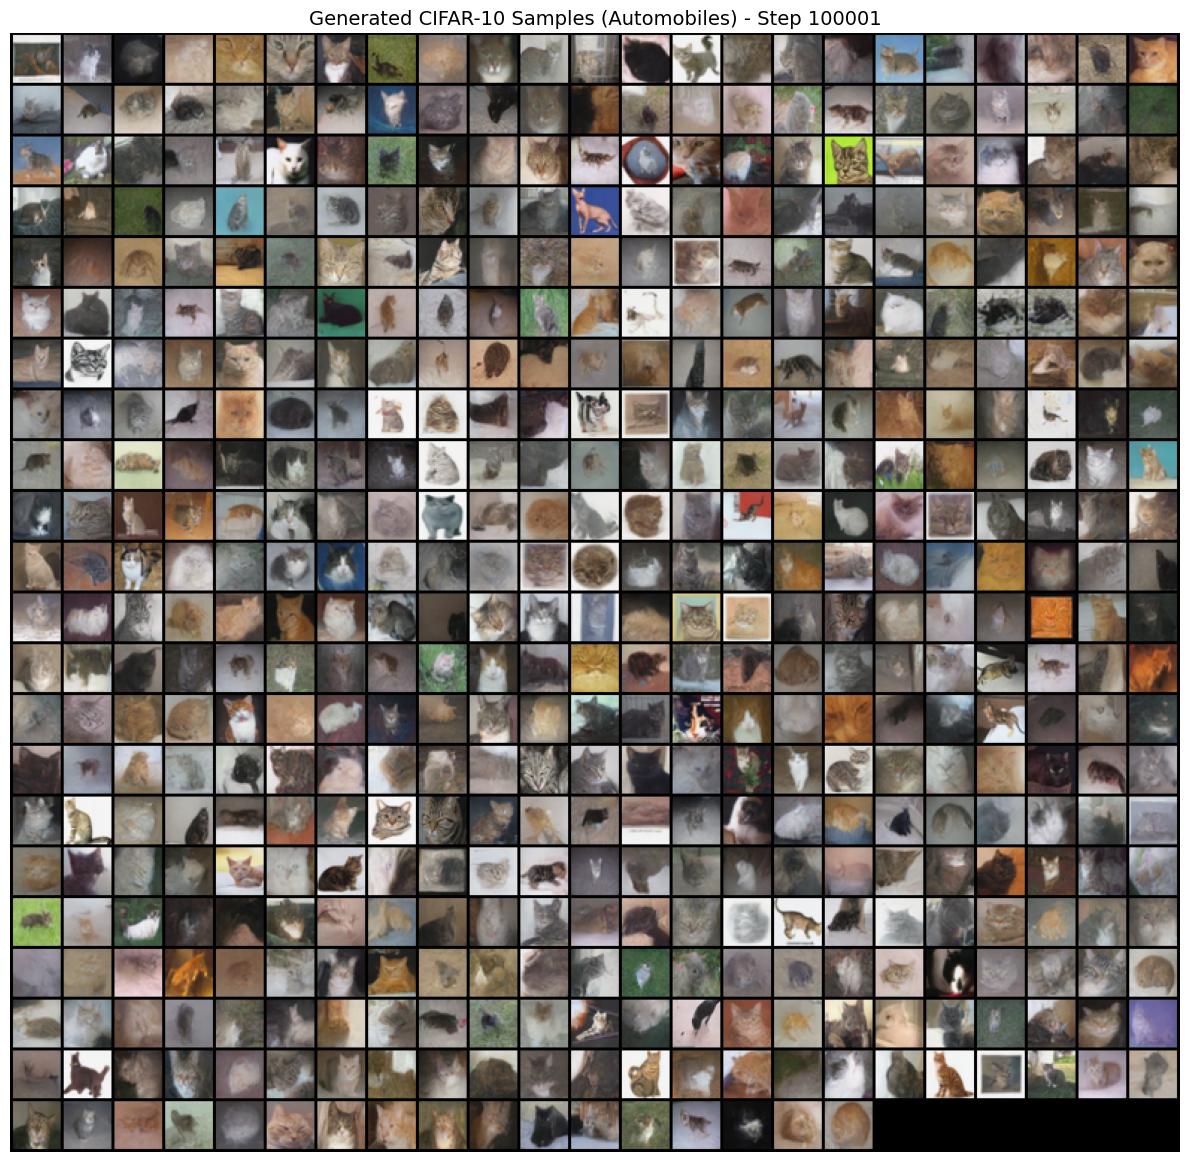


✓ Sample generation complete!


In [5]:
if ckpt_path:
    # ========================================================================
    # DTYPE FIX - Add this before sampling setup
    # ========================================================================
    import torch
    from models import utils as mutils
    
    print("Applying dtype fix for sampling...")
    
    # Patch the score function to auto-convert inputs to float32
    _original_get_score_fn = mutils.get_score_fn
    
    def get_score_fn_with_float_conversion(sde, model, train=False, continuous=False):
        original_score_fn = _original_get_score_fn(sde, model, train, continuous)
        
        def score_fn_float32(x, t):
            # Convert inputs to float32 before passing to model
            return original_score_fn(x.float(), t.float())
        
        return score_fn_float32
    
    # Apply the patch
    mutils.get_score_fn = get_score_fn_with_float_conversion
    print("✓ Dtype conversion patch applied!")
    
    # ========================================================================
    # Setup sampling (your original code)
    # ========================================================================
    num_samples = 500  # Generate 500 samples
    sampling_shape = (num_samples, config.data.num_channels, 
                      config.data.image_size, config.data.image_size)
    
    # Get sampling function
    inverse_scaler = datasets.get_data_inverse_scaler(config)
    
    if config.training.sde.lower() == 'vpsde':
        sde = sde_lib.VPSDE(beta_min=config.model.beta_min, beta_max=config.model.beta_max, 
                            N=config.model.num_scales)
        sampling_eps = 1e-3
    elif config.training.sde.lower() == 'subvpsde':
        sde = sde_lib.subVPSDE(beta_min=config.model.beta_min, beta_max=config.model.beta_max, 
                               N=config.model.num_scales)
        sampling_eps = 1e-3
    elif config.training.sde.lower() == 'vesde':
        sde = sde_lib.VESDE(sigma_min=config.model.sigma_min, sigma_max=config.model.sigma_max, 
                            N=config.model.num_scales)
        sampling_eps = 1e-5
    
    sampling_fn = sampling.get_sampling_fn(config, sde, sampling_shape, inverse_scaler, sampling_eps)
    
    print(f"Generating {num_samples} samples... (this may take a few minutes)")
    with torch.no_grad():
        samples, n_steps = sampling_fn(score_model)
    
    print(f"✓ Generated {num_samples} samples in {n_steps} steps")
    print(f"   Sample dtype: {samples.dtype}")
    print(f"   Sample shape: {samples.shape}")
    
    # Save samples
    os.makedirs('/kaggle/working/generated_samples', exist_ok=True)
    
    # Create image grid
    if num_samples > 1:
        nrow = min(23, num_samples)  # 8 images per row
        image_grid = make_grid(samples, nrow=nrow, padding=2, normalize=True)
    else:
        image_grid = samples[0]  # Single image
    
    save_image(image_grid, '/kaggle/working/generated_samples/sample_grid.png', normalize=True)
    
    # Also save individual samples
    for i in range(num_samples):
        save_image(samples[i], f'/kaggle/working/generated_samples/sample_{i:03d}.png', normalize=True)
    
    print(f"✓ Samples saved to /kaggle/working/generated_samples/")
    print(f"   - Grid: sample_grid.png")
    print(f"   - Individual: sample_000.png to sample_{num_samples-1:03d}.png")
    
    # Display the grid
    fig_size = (12, 12) if num_samples > 1 else (4, 4)
    plt.figure(figsize=fig_size)
    if len(image_grid.shape) == 3:  # Single image or grid (C, H, W)
        plt.imshow(image_grid.permute(1, 2, 0).cpu().numpy())
    else:  # Grayscale or already in HWC format
        plt.imshow(image_grid.cpu().numpy())
    plt.axis('off')
    plt.title(f'Generated CIFAR-10 Samples (Automobiles) - Step {state["step"]}', fontsize=14)
    plt.tight_layout()
    plt.savefig('/kaggle/working/generated_samples/display_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*60)
    print("✓ Sample generation complete!")
    print("="*60)
    
else:
    print("⚠ No checkpoint available. Please train the model first.")


In [8]:
if ckpt_path and 'samples' in locals():
    print("Calculating image quality metrics...")
    print("=" * 50)
    
    # 1. Pixel statistics
    print("\n1. Pixel Statistics:")
    print(f"   - Sample shape: {samples.shape}")
    print(f"   - Min value: {samples.min().item():.4f}")
    print(f"   - Max value: {samples.max().item():.4f}")
    print(f"   - Mean value: {samples.mean().item():.4f}")
    print(f"   - Std value: {samples.std().item():.4f}")
    
    # 2. Diversity metrics
    print("\n2. Sample Diversity:")
    # Calculate pairwise distances between samples
    samples_flat = samples.view(samples.shape[0], -1)
    distances = torch.cdist(samples_flat, samples_flat)
    # Get upper triangle (exclude diagonal)
    mask = torch.triu(torch.ones_like(distances), diagonal=1).bool()
    pairwise_dists = distances[mask]
    
    print(f"   - Mean pairwise distance: {pairwise_dists.mean().item():.4f}")
    print(f"   - Std pairwise distance: {pairwise_dists.std().item():.4f}")
    print(f"   - Min pairwise distance: {pairwise_dists.min().item():.4f}")
    print(f"   - Max pairwise distance: {pairwise_dists.max().item():.4f}")
    
    # 3. Per-channel statistics
    print("\n3. Per-Channel Statistics:")
    for i, channel in enumerate(['Red', 'Green', 'Blue']):
        channel_data = samples[:, i, :, :]
        print(f"   {channel}:")
        print(f"      - Mean: {channel_data.mean().item():.4f}")
        print(f"      - Std: {channel_data.std().item():.4f}")
    
    # 4. Compare with real data
    print("\n4. Comparison with Real Data:")
    print("   Loading a batch of real CIFAR-10 images (single class)...")
    
    # Get a batch of real images (same single class)
    TARGET_CLASS =  3 # Same as training (automobile)
    full_train_dataset = torch_datasets.CIFAR10(
        root='/kaggle/working/data',
        train=True,
        download=False,
        transform=transforms.Compose([transforms.ToTensor()])
    )
    
    # Filter for single class
    from torch.utils.data import Subset
    train_indices = [i for i, (_, label) in enumerate(full_train_dataset) if label == TARGET_CLASS]
    train_dataset = Subset(full_train_dataset, train_indices)
    
    real_loader = DataLoader(train_dataset, batch_size=num_samples, shuffle=True)
    real_batch, _ = next(iter(real_loader))
    real_batch = real_batch.to(config.device)
    
    # Apply same normalization as generated samples
    scaler = datasets.get_data_scaler(config)
    real_batch_scaled = scaler(real_batch)
    real_batch_scaled = inverse_scaler(real_batch_scaled)
    
    print(f"   Real images - Mean: {real_batch_scaled.mean().item():.4f}, Std: {real_batch_scaled.std().item():.4f}")
    print(f"   Generated   - Mean: {samples.mean().item():.4f}, Std: {samples.std().item():.4f}")
    
    # 5. Simple MSE between generated and real (not a perfect metric, but informative)
    print("\n5. Distribution Metrics:")
    # Compute histogram comparison
    real_hist = torch.histc(real_batch_scaled, bins=50, min=0, max=1)
    gen_hist = torch.histc(samples, bins=50, min=0, max=1)
    hist_diff = (real_hist - gen_hist).abs().sum().item()
    print(f"   - Histogram difference: {hist_diff:.2f}")
    
    print("\n" + "=" * 50)
    print("✓ Metrics calculation complete!")
    print("\nNote: For FID and Inception Score, you would need:")
    print("  - FID: Requires pre-trained Inception network (TensorFlow)")
    print("  - IS: Requires pre-trained Inception network (TensorFlow)")
    print("  These metrics are disabled in TensorFlow-free mode.")
else:
    print("⚠ No samples available. Generate samples first.")

Calculating image quality metrics...

1. Pixel Statistics:
   - Sample shape: torch.Size([500, 3, 32, 32])
   - Min value: -0.0639
   - Max value: 1.0441
   - Mean value: 0.4583
   - Std value: 0.2233

2. Sample Diversity:
   - Mean pairwise distance: 16.4569
   - Std pairwise distance: 5.2981
   - Min pairwise distance: 3.0086
   - Max pairwise distance: 48.2700

3. Per-Channel Statistics:
   Red:
      - Mean: 0.4933
      - Std: 0.2206
   Green:
      - Mean: 0.4577
      - Std: 0.2180
   Blue:
      - Mean: 0.4238
      - Std: 0.2257

4. Comparison with Real Data:
   Loading a batch of real CIFAR-10 images (single class)...
   Real images - Mean: 0.4505, Std: 0.2586
   Generated   - Mean: 0.4583, Std: 0.2233

5. Distribution Metrics:
   - Histogram difference: 346225.00

✓ Metrics calculation complete!

Note: For FID and Inception Score, you would need:
  - FID: Requires pre-trained Inception network (TensorFlow)
  - IS: Requires pre-trained Inception network (TensorFlow)
  These m

### Optional: Calculate FID Score (PyTorch-based)

If you want FID scores without TensorFlow, install pytorch-fid.

In [10]:
# Install pytorch-fid for FID calculation (PyTorch-based, no TensorFlow needed)
!pip install -q pytorch-fid

print("✓ pytorch-fid installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.8 MB/s eta 0:00:0000:01m0:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.5 MB/s eta 0:00:00:00:0100:01
^C
ERROR: Operation cancelled by user
✓ pytorch-fid installed


In [11]:
if ckpt_path and 'samples' in locals():
    import subprocess
    from PIL import Image
    
    # Prepare directories for FID calculation
    gen_dir = '/kaggle/working/fid_generated'
    real_dir = '/kaggle/working/fid_real'
    os.makedirs(gen_dir, exist_ok=True)
    os.makedirs(real_dir, exist_ok=True)
    
    print("Preparing images for FID calculation...")
    
    # Save generated samples as images
    for i in range(num_samples):
        img = samples[i].cpu()
        # Convert to PIL and save
        img_np = (img.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype('uint8')
        Image.fromarray(img_np).save(f'{gen_dir}/gen_{i:04d}.png')
    
    # Save real CIFAR-10 samples
    for i in range(num_samples):
        img = real_batch[i].cpu()
        img_np = (img.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype('uint8')
        Image.fromarray(img_np).save(f'{real_dir}/real_{i:04d}.png')
    
    print(f"✓ Saved {num_samples} generated and real images")
    
    # Calculate FID
    print("\nCalculating FID score...")
    try:
        result = subprocess.run(
            ['python', '-m', 'pytorch_fid', real_dir, gen_dir],
            capture_output=True,
            text=True,
            timeout=300
        )
        
        if result.returncode == 0:
            print("\n" + "=" * 50)
            print("FID SCORE:")
            print(result.stdout)
            print("=" * 50)
            
            # Extract FID value
            for line in result.stdout.split('\n'):
                if 'FID' in line or 'fid' in line.lower():
                    print(f"\n✓ {line}")
        else:
            print(f"Error calculating FID: {result.stderr}")
    except subprocess.TimeoutExpired:
        print("FID calculation timed out (5 minutes)")
    except Exception as e:
        print(f"Error: {e}")
    
    print("\n✓ FID calculation complete!")
else:
    print("⚠️ No samples available. Generate samples first.")

Preparing images for FID calculation...
✓ Saved 500 generated and real images

Calculating FID score...
Error calculating FID: /usr/bin/python3: No module named pytorch_fid


✓ FID calculation complete!


## Test Import (Optional)

Run this cell first to verify everything is installed correctly before starting the full training:

In [7]:
import torch
import torch.nn.functional as F_func
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision import datasets as torch_datasets, transforms
from torch.utils.data import DataLoader, Subset
from scipy import linalg
import numpy as np

# Make sure these exist in your environment:
# - ckpt_path
# - samples           # generated images, shape: (N, 3, H, W)
# - config.device     # e.g. 'cuda' or 'cpu'
# - state['step']     # training step (for logging)

if ckpt_path and 'samples' in locals():
    device = config.device if hasattr(config, "device") else torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # If num_samples is not already defined, infer from samples
    try:
        num_samples
    except NameError:
        num_samples = samples.shape[0]

    print("Calculating Inception Score...")
    print("=" * 50)

    # 1. Load pre-trained Inception v3 model
    print("\n1. Loading Inception v3 model...")
    inception_model = inception_v3(
        weights=Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False,   # we'll do our own normalization
        aux_logits=True         # not needed for evaluation
    )
    inception_model.eval()
    inception_model = inception_model.to(device)
    print("✓ Inception v3 loaded")

    # 2. Prepare samples for Inception Score calculation
    print("\n2. Preparing samples for Inception Score calculation...")

    # Ensure samples are float32 and on the correct device
    # (Inception v3 weights are float32, so inputs must be float32)
    samples = samples.to(device=device, dtype=torch.float32)

    # If your model outputs in [-1, 1], uncomment this to map to [0, 1]
    # samples = (samples + 1.0) / 2.0
    # samples = torch.clamp(samples, 0.0, 1.0)

    # Upsample images to 299x299 (Inception v3 input size)
    samples_299 = F_func.interpolate(samples, size=(299, 299),
                                     mode='bilinear', align_corners=False)

    # Normalize to ImageNet stats (Inception expects ImageNet normalization)
    # ImageNet mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1).to(device)
    samples_normalized = (samples_299 - mean) / std

    print(f"✓ Prepared {num_samples} samples (resized to 299x299)")

    print("\n3. Computing predictions...")

    def inception_score(imgs: torch.Tensor, batch_size: int = 32, splits: int = 10):
        """
        Computes the Inception Score of the generated images.

        Args:
            imgs: torch.Tensor of shape (N, 3, 299, 299)
            batch_size: batch size used to run Inception v3
            splits: number of splits used to compute IS
        """
        N = len(imgs)

        # Get predictions
        preds = []
        with torch.no_grad():
            for i in range(0, N, batch_size):
                batch = imgs[i:i + batch_size]
                # Ensure batch is on correct device and float32
                batch = batch.to(device=device, dtype=torch.float32)
                pred = inception_model(batch)
                pred = F_func.softmax(pred, dim=1)
                preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds, axis=0)

        # Compute Inception Score
        split_scores = []
        for k in range(splits):
            part = preds[k * (N // splits): (k + 1) * (N // splits), :]
            py = np.mean(part, axis=0)
            scores = []
            for i in range(part.shape[0]):
                pyx = part[i, :]
                scores.append(
                    np.sum(
                        pyx * (np.log(pyx + 1e-10) - np.log(py + 1e-10))
                    )
                )
            split_scores.append(np.exp(np.mean(scores)))

        return np.mean(split_scores), np.std(split_scores)

    # Calculate IS for generated samples
    is_mean, is_std = inception_score(
        samples_normalized,
        batch_size=min(32, num_samples),
        splits=min(10, num_samples)
    )

    print("\n" + "=" * 50)
    print("INCEPTION SCORE RESULTS:")
    print(f"  - Inception Score: {is_mean:.3f} ± {is_std:.3f}")
    print("=" * 50)

    print("\n📊 Interpretation:")
    print("  - Higher IS indicates better quality and diversity")
    print("  - CIFAR-10 ranges typically:")
    print("    • Random noise: ~1.0")
    print("    • Real CIFAR-10: ~11.0-12.0")
    print("    • Good generative models: ~8.0-10.0")
    print(f"  - Your model: {is_mean:.3f} (at step {state['step']})")

    # 4. Optional: Calculate IS for real images for comparison
    print("\n4. Computing Inception Score for real images (for comparison)...")

    TARGET_CLASS = 3  # e.g. automobile class in CIFAR-10

    full_train_dataset = torch_datasets.CIFAR10(
        root='/kaggle/working/data',
        train=True,
        download=False,
        transform=transforms.Compose([transforms.ToTensor()])
    )

    # Subset of real images from the target class
    train_indices = [i for i, (_, label) in enumerate(full_train_dataset) if label == TARGET_CLASS]
    train_dataset = Subset(full_train_dataset, train_indices[:num_samples])

    real_loader = DataLoader(train_dataset, batch_size=num_samples, shuffle=False)
    real_images, _ = next(iter(real_loader))

    # Move to device and ensure float32
    real_images = real_images.to(device=device, dtype=torch.float32)

    # Resize and normalize real images
    real_299 = F_func.interpolate(real_images, size=(299, 299),
                                  mode='bilinear', align_corners=False)
    real_normalized = (real_299 - mean) / std

    real_is_mean, real_is_std = inception_score(
        real_normalized,
        batch_size=min(32, num_samples),
        splits=min(10, num_samples)
    )

    print(f"\n  Real CIFAR-10 (class {TARGET_CLASS}) IS: {real_is_mean:.3f} ± {real_is_std:.3f}")
    print(f"  Generated samples IS: {is_mean:.3f} ± {is_std:.3f}")
    print(f"  Ratio (Generated/Real): {is_mean / real_is_mean:.2%}")

    print("\n" + "=" * 50)
    print("✓ Inception Score calculation complete!")
    print("=" * 50)

    # Clean up to save memory
    del inception_model
    torch.cuda.empty_cache()

else:
    print("⚠ No samples available. Generate samples first.")


Calculating Inception Score...

1. Loading Inception v3 model...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 210MB/s] 


✓ Inception v3 loaded

2. Preparing samples for Inception Score calculation...
✓ Prepared 500 samples (resized to 299x299)

3. Computing predictions...

INCEPTION SCORE RESULTS:
  - Inception Score: 4.116 ± 0.476

📊 Interpretation:
  - Higher IS indicates better quality and diversity
  - CIFAR-10 ranges typically:
    • Random noise: ~1.0
    • Real CIFAR-10: ~11.0-12.0
    • Good generative models: ~8.0-10.0
  - Your model: 4.116 (at step 100001)

4. Computing Inception Score for real images (for comparison)...

  Real CIFAR-10 (class 3) IS: 5.175 ± 0.416
  Generated samples IS: 4.116 ± 0.476
  Ratio (Generated/Real): 79.54%

✓ Inception Score calculation complete!


## Optional: Monitor Training

You can check the training progress by looking at the checkpoint directory:

In [ ]:
!ls -lh /kaggle/working/checkpoints/

---

## 📝 Complete Workflow Summary

### First-Time Setup:

**Part 1 - Install dependencies (run once):**
1. Cells 1-7: Check directories and setup paths
2. Cell 8: Install header
3. Cell 9: Install ml-collections and ninja
4. Cell 10: Remove TensorFlow packages
5. **⚠️ RESTART KERNEL** (Cell 11 instructions)

**Part 2 - After kernel restart:**
6. Cell 12: Header
7. Cell 13: Setup paths again
8. Cell 14: Check PyTorch/CUDA (pre-import dynamo)
9. Cell 15: Header
10. Cell 16: Load run_lib (TensorFlow-free)
11. Cell 17: Load configuration
12. Cell 18: **START TRAINING** 🚀
13. Cell 19: (Optional) Test setup
14. Cell 20: Monitor checkpoints

---

## ✨ Key Points:

- **No TensorFlow!** - We patch imports to bypass TensorFlow dependencies
- **Kernel restart required** - After uninstalling TensorFlow, restart to clear cached imports
- **Training works fully** - All PyTorch training functionality works
- **FID evaluation disabled** - Metric evaluation skipped (not critical for training)

---

**Training Process:**
- Downloads CIFAR-10 automatically
- Trains score-based diffusion model
- Saves checkpoints every 5,000 iterations  
- Logs training loss every 50 iterations
- Saves to `/kaggle/working/checkpoints/`
- Resumes from checkpoints automatically

**Important:** If you see torch._dynamo errors, restart the kernel and run from Cell 13 onwards.